# CONEXIÓN MySQL

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text

In [2]:
DB_USER= "root"
DB_PASSWORD= "contraseña_root24"
DB_HOST= "localhost"
DB_PORT= 3306
DB_NAME= "accidentes_db"

CSV_PATH= "C:/Users/vinis/Desktop/VSC Codigos/Python/DGT_PRJCT/accidentes_consolidado.csv"

In [6]:
engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    echo=False
)


with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("✅ Conexión establecida correctamente.")

✅ Conexión establecida correctamente.


CREACIÓN DE 4 TABLAS 

In [8]:
# Celda 4 — Crear las 4 tablas
ddl_statements = [
"""
CREATE TABLE IF NOT EXISTS accidentes (
    id_accidente_global     VARCHAR(20)     NOT NULL,
    id_accidente            VARCHAR(20),
    anyo                    SMALLINT,
    mes                     TINYINT,
    dia_semana              TINYINT,
    hora                    TINYINT,
    cod_provincia           SMALLINT,
    cod_municipio           INT,
    isla                    VARCHAR(50),
    zona                    VARCHAR(100),
    zona_agrupada           VARCHAR(50),
    carretera               VARCHAR(50),
    km                      DECIMAL(8,3),
    sentido_1f              VARCHAR(100),
    titularidad_via         VARCHAR(50),
    tipo_via                VARCHAR(100),
    tipo_accidente          VARCHAR(100),
    total_vehiculos         SMALLINT,
    nudo                    VARCHAR(50),
    nudo_info               VARCHAR(200),
    carretera_cruce         VARCHAR(50),
    trazado_planta          VARCHAR(100),
    acera                   VARCHAR(50),
    PRIMARY KEY (id_accidente_global)
) ENGINE=InnoDB;
""",
"""
CREATE TABLE IF NOT EXISTS victimas (
    id_accidente_global     VARCHAR(20)     NOT NULL,
    mu24h                   TINYINT         DEFAULT 0,
    hg24h                   TINYINT         DEFAULT 0,
    hl24h                   TINYINT         DEFAULT 0,
    total_victimas_24h      SMALLINT        DEFAULT 0,
    mu30df                  TINYINT         DEFAULT 0,
    hg30df                  TINYINT         DEFAULT 0,
    hl30df                  TINYINT         DEFAULT 0,
    total_victimas_30df     SMALLINT        DEFAULT 0,
    PRIMARY KEY (id_accidente_global),
    FOREIGN KEY (id_accidente_global) REFERENCES accidentes(id_accidente_global) ON DELETE CASCADE
) ENGINE=InnoDB;
""",
"""
CREATE TABLE IF NOT EXISTS vehiculos_implicados (
    id_accidente_global         VARCHAR(20)     NOT NULL,
    peat_mu24h                  TINYINT         DEFAULT 0,
    bici_mu24h                  TINYINT         DEFAULT 0,
    ciclo_mu24h                 TINYINT         DEFAULT 0,
    moto_mu24h                  TINYINT         DEFAULT 0,
    tur_mu24h                   TINYINT         DEFAULT 0,
    furg_mu24h                  TINYINT         DEFAULT 0,
    cam_menos3500_mu24h         TINYINT         DEFAULT 0,
    cam_mas3500_mu24h           TINYINT         DEFAULT 0,
    bus_mu24h                   TINYINT         DEFAULT 0,
    otro_mu24h                  TINYINT         DEFAULT 0,
    sinespecif_mu24h            TINYINT         DEFAULT 0,
    peat_mu30df                 TINYINT         DEFAULT 0,
    bici_mu30df                 TINYINT         DEFAULT 0,
    ciclo_mu30df                TINYINT         DEFAULT 0,
    moto_mu30df                 TINYINT         DEFAULT 0,
    tur_mu30df                  TINYINT         DEFAULT 0,
    furg_mu30df                 TINYINT         DEFAULT 0,
    cam_menos3500_mu30df        TINYINT         DEFAULT 0,
    cam_mas3500_mu30df          TINYINT         DEFAULT 0,
    bus_mu30df                  TINYINT         DEFAULT 0,
    vmp_mu30df                  TINYINT         DEFAULT 0,
    otro_mu30df                 TINYINT         DEFAULT 0,
    sinespecif_mu30df           TINYINT         DEFAULT 0,
    PRIMARY KEY (id_accidente_global),
    FOREIGN KEY (id_accidente_global) REFERENCES accidentes(id_accidente_global) ON DELETE CASCADE
) ENGINE=InnoDB;
""",
"""
CREATE TABLE IF NOT EXISTS condiciones_accidente (
    id_accidente_global         VARCHAR(20)     NOT NULL,
    condicion_nivel_circula     VARCHAR(100),
    condicion_firme             VARCHAR(100),
    condicion_iluminacion       VARCHAR(100),
    condicion_meteo             VARCHAR(100),
    condicion_niebla            VARCHAR(100),
    condicion_viento            VARCHAR(100),
    visib_restringida_por       VARCHAR(100),
    priori_norma                TINYINT(1)      DEFAULT 0,
    priori_agente               TINYINT(1)      DEFAULT 0,
    priori_semaforo             TINYINT(1)      DEFAULT 0,
    priori_vert_stop            TINYINT(1)      DEFAULT 0,
    priori_vert_ceda            TINYINT(1)      DEFAULT 0,
    priori_horiz_stop           TINYINT(1)      DEFAULT 0,
    priori_horiz_ceda           TINYINT(1)      DEFAULT 0,
    priori_marcas               TINYINT(1)      DEFAULT 0,
    priori_pea_no_elev          TINYINT(1)      DEFAULT 0,
    priori_pea_elev             TINYINT(1)      DEFAULT 0,
    priori_marca_ciclos         TINYINT(1)      DEFAULT 0,
    priori_circunstancial       TINYINT(1)      DEFAULT 0,
    priori_otra                 TINYINT(1)      DEFAULT 0,
    PRIMARY KEY (id_accidente_global),
    FOREIGN KEY (id_accidente_global) REFERENCES accidentes(id_accidente_global) ON DELETE CASCADE
) ENGINE=InnoDB;
"""
]

with engine.begin() as conn:
    conn.execute(text(f"USE {DB_NAME};"))
    for ddl in ddl_statements:
        conn.execute(text(ddl))

print("Las 4 tablas creadas correctamente.")

Las 4 tablas creadas correctamente.


In [9]:
df_dgt = pd.read_csv(CSV_PATH, sep=";", encoding="utf-8", low_memory=False)
df_dgt.columns = df_dgt.columns.str.strip().str.upper()
print(f"CSV cargado: {len(df_dgt):,} filas | {len(df_dgt.columns)} columnas")


CSV cargado: 875,013 filas | 76 columnas


In [10]:
COLS_ACCIDENTES = [
    "ID_ACCIDENTE_GLOBAL", "ID_ACCIDENTE", "ANYO", "MES", "DIA_SEMANA", "HORA",
    "COD_PROVINCIA", "COD_MUNICIPIO", "ISLA", "ZONA", "ZONA_AGRUPADA",
    "CARRETERA", "KM", "SENTIDO_1F", "TITULARIDAD_VIA", "TIPO_VIA",
    "TIPO_ACCIDENTE", "TOTAL_VEHICULOS", "NUDO", "NUDO_INFO",
    "CARRETERA_CRUCE", "TRAZADO_PLANTA", "ACERA"
]

COLS_VICTIMAS = [
    "ID_ACCIDENTE_GLOBAL",
    "TOTAL_MU24H", "TOTAL_HG24H", "TOTAL_HL24H", "TOTAL_VICTIMAS_24H",
    "TOTAL_MU30DF", "TOTAL_HG30DF", "TOTAL_HL30DF", "TOTAL_VICTIMAS_30DF"
]

COLS_VEHICULOS = [
    "ID_ACCIDENTE_GLOBAL",
    "TOT_PEAT_MU24H", "TOT_BICI_MU24H", "TOT_CICLO_MU24H", "TOT_MOTO_MU24H",
    "TOT_TUR_MU24H", "TOT_FURG_MU24H", "TOT_CAM_MENOS3500_MU24H",
    "TOT_CAM_MAS3500_MU24H", "TOT_BUS_MU24H", "TOT_OTRO_MU24H",
    "TOT_SINESPECIF_MU24H",
    "TOT_PEAT_MU30DF", "TOT_BICI_MU30DF", "TOT_CICLO_MU30DF", "TOT_MOTO_MU30DF",
    "TOT_TUR_MU30DF", "TOT_FURG_MU30DF", "TOT_CAM_MENOS3500_MU30DF",
    "TOT_CAM_MAS3500_MU30DF", "TOT_BUS_MU30DF", "TOT_VMP_MU30DF",
    "TOT_OTRO_MU30DF", "TOT_SINESPECIF_MU30DF"
]

COLS_CONDICIONES = [
    "ID_ACCIDENTE_GLOBAL",
    "CONDICION_NIVEL_CIRCULA", "CONDICION_FIRME", "CONDICION_ILUMINACION",
    "CONDICION_METEO", "CONDICION_NIEBLA", "CONDICION_VIENTO",
    "VISIB_RESTRINGIDA_POR",
    "PRIORI_NORMA", "PRIORI_AGENTE", "PRIORI_SEMAFORO", "PRIORI_VERT_STOP",
    "PRIORI_VERT_CEDA", "PRIORI_HORIZ_STOP", "PRIORI_HORIZ_CEDA",
    "PRIORI_MARCAS", "PRIORI_PEA_NO_ELEV", "PRIORI_PEA_ELEV",
    "PRIORI_MARCA_CICLOS", "PRIORI_CIRCUNSTANCIAL", "PRIORI_OTRA"
]


In [15]:
df = pd.read_csv(
    r"C:\ProgramData\MySQL\MySQL Server 9.2\Uploads\accidentes_consolidado.csv",
    sep=";",
    encoding="utf-8",
    nrows=0
)
print(f"Total columnas: {len(df.columns)}")
print(list(df.columns))

Total columnas: 76
['ID_ACCIDENTE_GLOBAL', 'SECUENCIAL', 'ANYO', 'MES', 'DIA_SEMANA', 'HORA', 'COD_PROVINCIA', 'COD_MUNICIPIO', 'ISLA', 'ZONA', 'ZONA_AGRUPADA', 'CARRETERA', 'KM', 'SENTIDO_1F', 'TITULARIDAD_VIA', 'TIPO_VIA', 'TIPO_ACCIDENTE', 'TOTAL_MU24H', 'TOTAL_HG24H', 'TOTAL_HL24H', 'TOTAL_VICTIMAS_24H', 'TOTAL_MU30DF', 'TOTAL_HG30DF', 'TOTAL_HL30DF', 'TOTAL_VICTIMAS_30DF', 'TOTAL_VEHICULOS', 'TOT_PEAT_MU24H', 'TOT_BICI_MU24H', 'TOT_CICLO_MU24H', 'TOT_MOTO_MU24H', 'TOT_TUR_MU24H', 'TOT_FURG_MU24H', 'TOT_CAM_MENOS3500_MU24H', 'TOT_CAM_MAS3500_MU24H', 'TOT_BUS_MU24H', 'TOT_OTRO_MU24H', 'TOT_SINESPECIF_MU24H', 'TOT_PEAT_MU30DF', 'TOT_BICI_MU30DF', 'TOT_CICLO_MU30DF', 'TOT_MOTO_MU30DF', 'TOT_TUR_MU30DF', 'TOT_FURG_MU30DF', 'TOT_CAM_MENOS3500_MU30DF', 'TOT_CAM_MAS3500_MU30DF', 'TOT_BUS_MU30DF', 'TOT_OTRO_MU30DF', 'TOT_SINESPECIF_MU30DF', 'NUDO', 'NUDO_INFO', 'CARRETERA_CRUCE', 'PRIORI_NORMA', 'PRIORI_AGENTE', 'PRIORI_SEMAFORO', 'PRIORI_VERT_STOP', 'PRIORI_VERT_CEDA', 'PRIORI_HORIZ_STOP'

SEGUNDA VUELTA CONEXIÓN PYTHON - MySQL

In [17]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="contraseña_root24",
    database="accidentes_db"
)

cursor = conn.cursor()

# Verificar conexión
cursor.execute("SELECT COUNT(*) FROM temp_accidentes")
print(cursor.fetchone())

(2625039,)


In [18]:
cursor.execute("TRUNCATE TABLE temp_accidentes")
conn.commit()
print("✅ Tabla temporal limpiada")

✅ Tabla temporal limpiada


In [20]:
cursor.execute("SELECT COUNT(*) FROM temp_accidentes")
print(cursor.fetchone())

(0,)


In [23]:
import numpy as np
# Leer CSV en chunks para no saturar memoria
CSV_PATH = "accidentes_consolidado.csv"

chunk_size = 50_000
chunks = pd.read_csv(CSV_PATH, sep=";", encoding="utf-8", chunksize=chunk_size, low_memory=False)

# Insertar chunk a chunk
total = 0
for chunk in chunks:
    chunk.columns = chunk.columns.str.strip().str.lower()
    
    # Reemplazar NaN y 'nan' por None
    chunk = chunk.replace({np.nan: None, 'nan': None, 'NaN': None})
    
    placeholders = ", ".join(["%s"] * len(chunk.columns))
    columns = ", ".join(chunk.columns)
    sql = f"INSERT INTO temp_accidentes ({columns}) VALUES ({placeholders})"
    
    data = chunk.values.tolist()
    
    cursor.executemany(sql, data)
    conn.commit()
    total += len(chunk)
    print(f"  Insertadas {total:,} filas...")

print(f"✅ Total cargado: {total:,} filas")

  Insertadas 50,000 filas...
  Insertadas 100,000 filas...
  Insertadas 150,000 filas...
  Insertadas 200,000 filas...
  Insertadas 250,000 filas...
  Insertadas 300,000 filas...
  Insertadas 350,000 filas...
  Insertadas 400,000 filas...
  Insertadas 450,000 filas...
  Insertadas 500,000 filas...
  Insertadas 550,000 filas...
  Insertadas 600,000 filas...
  Insertadas 650,000 filas...
  Insertadas 700,000 filas...
  Insertadas 750,000 filas...
  Insertadas 800,000 filas...
  Insertadas 850,000 filas...
  Insertadas 875,013 filas...
✅ Total cargado: 875,013 filas


In [24]:
queries = [
    """
    INSERT INTO accidentes
    SELECT 
        id_accidente_global, id_accidente, anyo, mes, dia_semana, hora,
        cod_provincia, cod_municipio, isla, zona, zona_agrupada,
        carretera, NULLIF(TRIM(REPLACE(km, ',', '.')), '') AS km,
        sentido_1f, titularidad_via, tipo_via, tipo_accidente,
        total_vehiculos, nudo, nudo_info, carretera_cruce, trazado_planta, acera
    FROM temp_accidentes
    """,
    """
    INSERT INTO victimas
    SELECT 
        id_accidente_global,
        total_mu24h, total_hg24h, total_hl24h, total_victimas_24h,
        total_mu30df, total_hg30df, total_hl30df, total_victimas_30df
    FROM temp_accidentes
    """,
    """
    INSERT INTO vehiculos_implicados
    SELECT
        id_accidente_global,
        tot_peat_mu24h, tot_bici_mu24h, tot_ciclo_mu24h, tot_moto_mu24h,
        tot_tur_mu24h, tot_furg_mu24h, tot_cam_menos3500_mu24h,
        tot_cam_mas3500_mu24h, tot_bus_mu24h, tot_otro_mu24h,
        tot_sinespecif_mu24h,
        tot_peat_mu30df, tot_bici_mu30df, tot_ciclo_mu30df, tot_moto_mu30df,
        tot_tur_mu30df, tot_furg_mu30df, tot_cam_menos3500_mu30df,
        tot_cam_mas3500_mu30df, tot_bus_mu30df, tot_vmp_mu30df,
        tot_otro_mu30df, tot_sinespecif_mu30df
    FROM temp_accidentes
    """,
    """
    INSERT INTO condiciones_accidente
    SELECT
        id_accidente_global,
        condicion_nivel_circula, condicion_firme, condicion_iluminacion,
        condicion_meteo, condicion_niebla, condicion_viento,
        visib_restringida_por,
        priori_norma, priori_agente, priori_semaforo, priori_vert_stop,
        priori_vert_ceda, priori_horiz_stop, priori_horiz_ceda,
        priori_marcas, priori_pea_no_elev, priori_pea_elev,
        priori_marca_ciclos, priori_circunstancial, priori_otra
    FROM temp_accidentes
    """
]

tablas = ["accidentes", "victimas", "vehiculos_implicados", "condiciones_accidente"]

cursor.execute("SET SESSION sql_mode = ''")

for query, tabla in zip(queries, tablas):
    print(f"Cargando '{tabla}'...")
    cursor.execute(query)
    conn.commit()
    print(f"✅ '{tabla}' cargada: {cursor.rowcount:,} filas")

Cargando 'accidentes'...
✅ 'accidentes' cargada: 875,013 filas
Cargando 'victimas'...
✅ 'victimas' cargada: 875,013 filas
Cargando 'vehiculos_implicados'...
✅ 'vehiculos_implicados' cargada: 875,013 filas
Cargando 'condiciones_accidente'...
✅ 'condiciones_accidente' cargada: 875,013 filas


In [25]:
tablas = ["accidentes", "victimas", "vehiculos_implicados", "condiciones_accidente"]

for tabla in tablas:
    cursor.execute(f"SELECT COUNT(*) FROM {tabla}")
    count = cursor.fetchone()[0]
    print(f"{tabla}: {count:,} filas")

accidentes: 875,013 filas
victimas: 875,013 filas
vehiculos_implicados: 875,013 filas
condiciones_accidente: 875,013 filas


In [26]:
cursor.execute("DROP TABLE temp_accidentes")
conn.commit()
cursor.close()
conn.close()
print("✅ Tabla temporal eliminada y conexión cerrada.")


✅ Tabla temporal eliminada y conexión cerrada.


In [11]:

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import mysql.connector

# Estilo general
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"] = "sans-serif"

# Conexión a MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="contraseña_root24",
    database="accidentes_db"
)
print("✅ Conexión establecida")

✅ Conexión establecida


In [12]:
import pandas as pd
query_temporal = """
SELECT
    a.anyo,
    COUNT(*)                                    AS total_accidentes,
    SUM(v.mu24h)                                AS total_muertos_24h,
    SUM(v.mu30df)                               AS total_muertos_30df,
    ROUND(SUM(v.mu24h) / COUNT(*) * 1000, 2)   AS tasa_mortalidad_por_1000
FROM accidentes a
JOIN victimas v ON a.id_accidente_global = v.id_accidente_global
GROUP BY a.anyo
ORDER BY a.anyo
"""

query_provincias = """
SELECT
    a.cod_provincia,
    p.provincia,
    COUNT(*)                                    AS total_accidentes,
    SUM(v.mu30df)                               AS total_muertos_30df,
    ROUND(SUM(v.mu30df) / COUNT(*) * 1000, 2)  AS tasa_mortalidad_por_1000
FROM accidentes a
JOIN victimas v      ON a.id_accidente_global = v.id_accidente_global
JOIN ine_cod_prov p  ON a.cod_provincia = p.cod_provincia
WHERE a.cod_provincia IS NOT NULL
GROUP BY a.cod_provincia, p.provincia
ORDER BY total_accidentes DESC
LIMIT 15
"""

query_meteo = """
SELECT
    m.valor                                     AS condicion,
    COUNT(*)                                    AS total_accidentes,
    SUM(v.mu30df)                               AS total_muertos_30df,
    ROUND(SUM(v.mu30df) / COUNT(*) * 1000, 2)  AS tasa_mortalidad_por_1000
FROM accidentes a
JOIN victimas v              ON a.id_accidente_global = v.id_accidente_global
JOIN condiciones_accidente c ON a.id_accidente_global = c.id_accidente_global
JOIN tabla_meteo m           ON c.condicion_meteo = m.etiqueta
WHERE c.condicion_meteo IS NOT NULL
GROUP BY c.condicion_meteo, m.valor
ORDER BY total_accidentes DESC
"""

df_temporal    = pd.read_sql(query_temporal,    conn)
df_provincias  = pd.read_sql(query_provincias,  conn)
df_meteo       = pd.read_sql(query_meteo,       conn)

print("✅ Datos cargados correctamente")
print(f"  Temporal:   {len(df_temporal)} filas")
print(f"  Provincias: {len(df_provincias)} filas")
print(f"  Meteo:      {len(df_meteo)} filas")


C:\Users\vinis\AppData\Local\Temp\ipykernel_24684\3075580028.py:46: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

C:\Users\vinis\AppData\Local\Temp\ipykernel_24684\3075580028.py:47: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.

C:\Users\vinis\AppData\Local\Temp\ipykernel_24684\3075580028.py:48: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



✅ Datos cargados correctamente
  Temporal:   9 filas
  Provincias: 15 filas
  Meteo:      8 filas


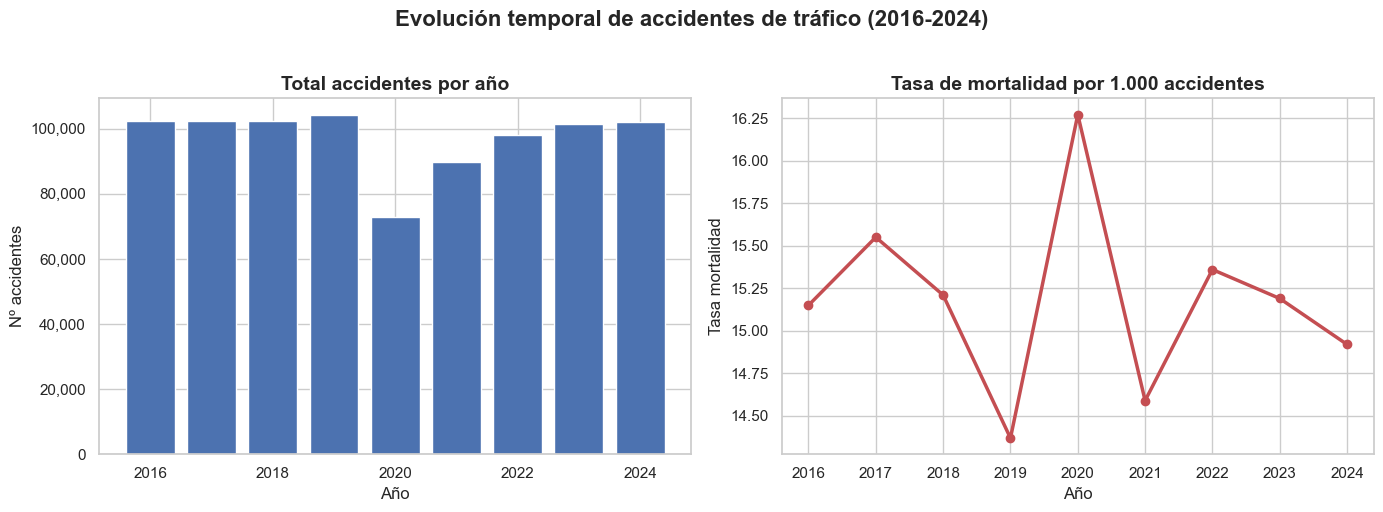

In [5]:
# EVOLUCIÓN TEMPORAL DE ACCIDENTES

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Total accidentes por año
axes[0].bar(df_temporal["anyo"], df_temporal["total_accidentes"], color="#4C72B0")
axes[0].set_title("Total accidentes por año", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Nº accidentes")
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Gráfico 2: Tasa de mortalidad por año
axes[1].plot(df_temporal["anyo"], df_temporal["tasa_mortalidad_por_1000"],
             marker="o", color="#C44E52", linewidth=2.5)
axes[1].set_title("Tasa de mortalidad por 1.000 accidentes", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Tasa mortalidad")

plt.suptitle("Evolución temporal de accidentes de tráfico (2016-2024)",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("evolucion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\vinis\AppData\Local\Temp\ipykernel_24684\1410286705.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_provincias, x="total_accidentes", y="provincia",
C:\Users\vinis\AppData\Local\Temp\ipykernel_24684\1410286705.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_provincias.sort_values("tasa_mortalidad_por_1000", ascending=False),


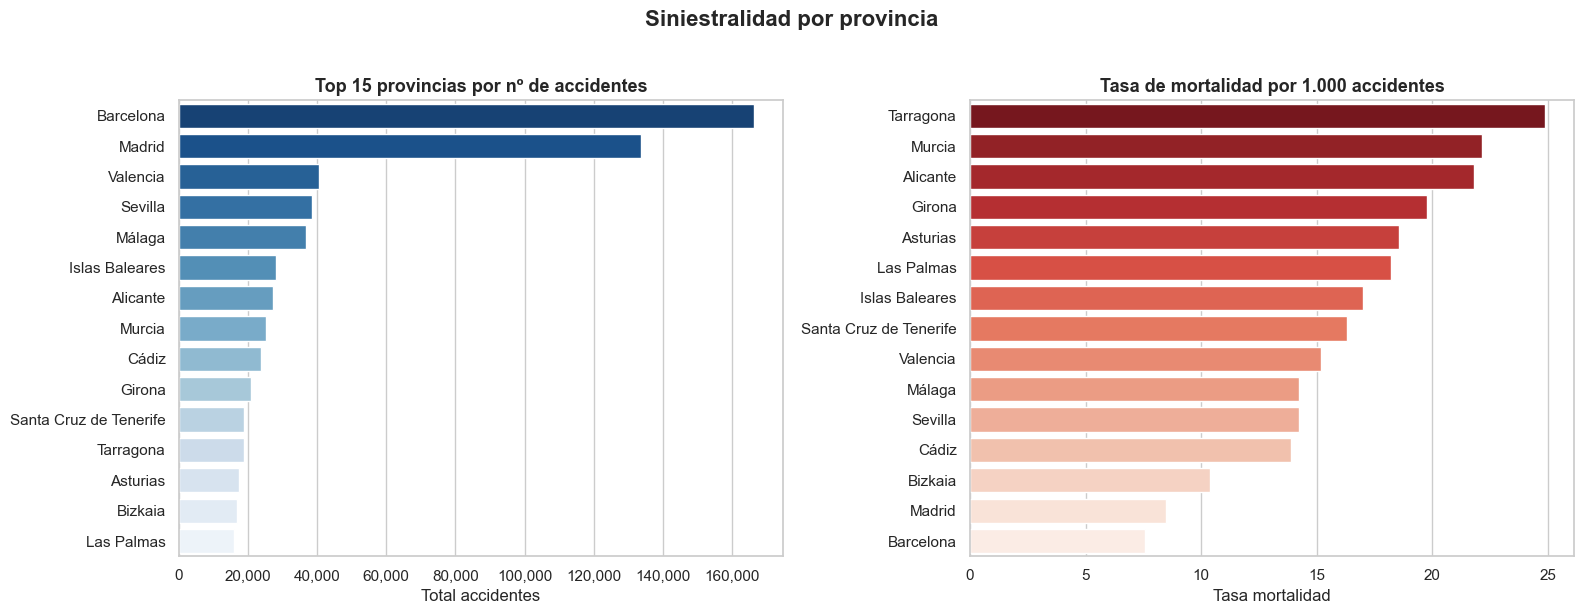

In [6]:
# ACCIDENTES POR PROVINCIA

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Total accidentes por provincia
sns.barplot(data=df_provincias, x="total_accidentes", y="provincia",
            palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 15 provincias por nº de accidentes", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Total accidentes")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Gráfico 2: Tasa mortalidad por provincia
sns.barplot(data=df_provincias.sort_values("tasa_mortalidad_por_1000", ascending=False),
            x="tasa_mortalidad_por_1000", y="provincia",
            palette="Reds_r", ax=axes[1])
axes[1].set_title("Tasa de mortalidad por 1.000 accidentes", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tasa mortalidad")
axes[1].set_ylabel("")

plt.suptitle("Siniestralidad por provincia", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("siniestralidad_provincias.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# CONDICIONES METEOROLÓGICAS

fig = px.scatter(
    df_meteo,
    x="total_accidentes",
    y="tasa_mortalidad_por_1000",
    size="total_muertos_30df",
    color="condicion",
    text="condicion",
    title="Frecuencia vs Mortalidad según condición meteorológica",
    labels={
        "total_accidentes": "Total accidentes",
        "tasa_mortalidad_por_1000": "Tasa mortalidad por 1.000",
        "condicion": "Condición meteorológica"
    }
)
fig.update_traces(textposition="top center")
fig.update_layout(showlegend=False, height=500)
fig.show()


# MACHINE LEARNING

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import mysql.connector
import warnings
warnings.filterwarnings("ignore")

In [16]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="contraseña_root24",
    database="accidentes_db"
)

query = """
SELECT
    a.cod_provincia,
    a.dia_semana,
    a.hora,
    a.zona_agrupada,
    a.tipo_via,
    a.tipo_accidente,
    c.condicion_meteo,
    v.mu30df
FROM accidentes a
JOIN victimas v              ON a.id_accidente_global = v.id_accidente_global
JOIN condiciones_accidente c ON a.id_accidente_global = c.id_accidente_global
WHERE a.hora IS NOT NULL
  AND a.tipo_via IS NOT NULL
  AND a.tipo_accidente IS NOT NULL
  AND c.condicion_meteo IS NOT NULL
  AND a.zona_agrupada IS NOT NULL
"""

df = pd.read_sql(query, conn)
print(f"✅ Datos cargados: {len(df):,} filas")


✅ Datos cargados: 874,893 filas


In [29]:
df["mortal"] = (df["mu30df"] > 0).astype(int)

print(f"Accidentes mortales:    {df['mortal'].sum():,} ({df['mortal'].mean()*100:.1f}%)")
print(f"Accidentes no mortales: {(df['mortal']==0).sum():,} ({(df['mortal']==0).mean()*100:.1f}%)")

# Crear franja horaria
def franja_horaria(hora):
    if 6 <= hora < 13:      return "mañana"       # 06:00 - 12:59
    elif 13 <= hora < 20:   return "tarde"         # 13:00 - 19:59
    elif 20 <= hora <= 23:  return "noche"         # 20:00 - 23:59
    else:                   return "madrugada"     # 00:00 - 05:59

df["franja_horaria"] = df["hora"].apply(franja_horaria)

# Codificar variables categóricas
le = LabelEncoder()
for col in ["franja_horaria", "zona_agrupada", "tipo_via", "tipo_accidente"]:
    df[col] = le.fit_transform(df[col].astype(str))

FEATURES = [
    "cod_provincia", "dia_semana", "franja_horaria",
    "zona_agrupada", "tipo_via", "tipo_accidente", "condicion_meteo"
]

X = df[FEATURES]
y = df["mortal"]


Accidentes mortales:    14,332 (1.6%)
Accidentes no mortales: 860,561 (98.4%)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} filas")
print(f"Test:  {len(X_test):,} filas")


Train: 699,914 filas
Test:  174,979 filas


In [31]:
modelo = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [32]:
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No mortal", "Mortal"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Classification Report:
              precision    recall  f1-score   support

   No mortal       0.99      0.65      0.78    172113
      Mortal       0.03      0.70      0.06      2866

    accuracy                           0.65    174979
   macro avg       0.51      0.68      0.42    174979
weighted avg       0.98      0.65      0.77    174979

ROC-AUC: 0.7057


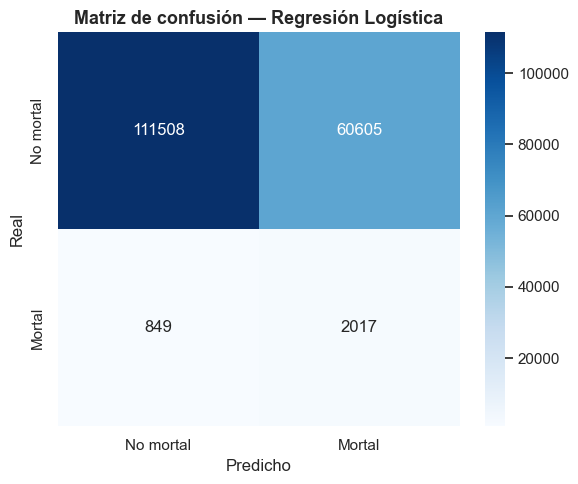

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No mortal", "Mortal"],
            yticklabels=["No mortal", "Mortal"])
plt.title("Matriz de confusión — Regresión Logística", fontsize=13, fontweight="bold")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


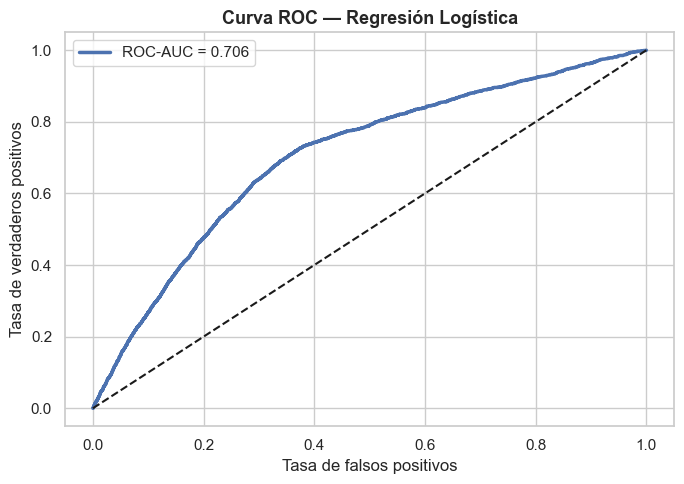

In [34]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#4C72B0", linewidth=2.5, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.title("Curva ROC — Regresión Logística", fontsize=13, fontweight="bold")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.savefig("curva_roc.png", dpi=150, bbox_inches="tight")
plt.show()


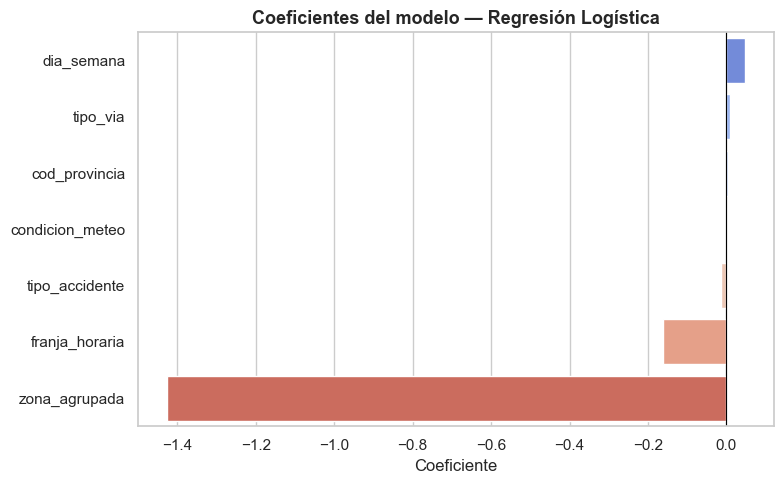

In [35]:
coeficientes = pd.DataFrame({
    "feature":     FEATURES,
    "coeficiente": modelo.coef_[0]
}).sort_values("coeficiente", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=coeficientes, x="coeficiente", y="feature", palette="coolwarm")
plt.title("Coeficientes del modelo — Regresión Logística", fontsize=13, fontweight="bold")
plt.xlabel("Coeficiente")
plt.ylabel("")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("coeficientes.png", dpi=150, bbox_inches="tight")
plt.show()